<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Relatividad-y-gravitacion/ps2_RG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Relatividad y Gravitación</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Problem Set 2</center></b><h2>
<h3><b><center>Transformaciones de Lorentz-Einsteins</center></b><h3>
<h5><center><b>Asignada</b>: Jueves 12 de Septiembre de 2024</center><h5>
<h5><center><b>Entrega</b>: Jueves 19 de septiembre de 2024</center><h5>




Juan manuel cardenas

### **Solucion de los puntos computacionales: 3 y parte del 4**

Simplemente se tomo el mismo notebook del ps2 del profesor, se solucionaron los puntos que tenian parte computacional que son el 3 y una parte del 4. No se eliminaron los enunciados de los otros puntos no computacionales, se pasaron para el final del notebook.
___


<br><br>

3. Vamos a representar gráficamente las transformaciones de velocidades. Para ello vamos a suponer que desde el origen de coordenadas del sistema del experimento (O') salen partículas con rapidez idéntica $v_L$ en todas direcciones.

  a. Escoja N direcciones del espacio y dibuje usando `quiver` (o un comando análogo) los vectores de velocidad correspondientes a cada dirección.

  b. Aplique las reglas de conversión de velocidades en la configuración estándar para encontrar las componentes de la velocidad medidas en el laboratorio. El gráfico se debe parece a la figura abajo.

  c. Construya un código interactivo que le permita modificar tanto la velocidad relativa entre los sistemas de referencia $u_L$ y la rapidez de las partículas $v_L$.

  d. Escoja $v_L=1$ (fotones). ¿Qué diferencias observa entre el caso de $v_L<1$ y el caso de los fotones?.

grafico esperado:



  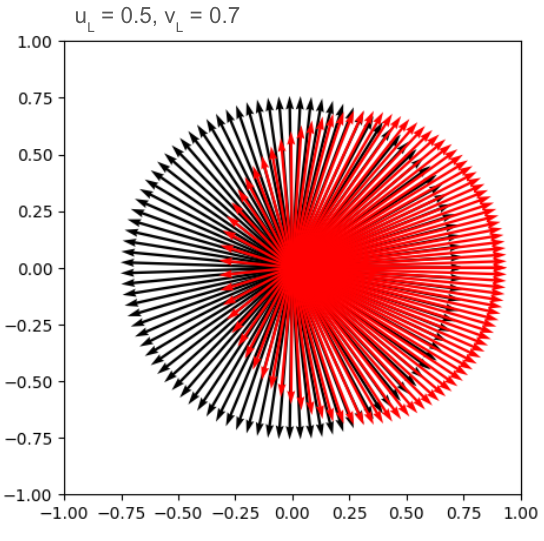

### **Transformacion relativista para velocidades**

Bajo la configuracion estandar, en este caso se tienen las velocidades primadas; las de la fuente de luz, y se desean encontrar las velocidades del observador no primado; el de la tierra. Creando una funcion para obtener las velocidades del MR(O) a partir de las del MR(O') usando las transformaciones inversas para velocidades:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

def TLE_velocity(vxp, vyp, u):
  """Transformacion de velocidades del MrO' al MrO"""

  gamma = 1/(np.sqrt(1-u**2))
  vx = (vxp + u) / (1+u*vxp)
  vy = vyp / (gamma*(1+u*vxp))

  return vx, vy

**Interactivo** de las transformaciones LE's para la velocidad

In [ ]:
n = 100 # numero de vectores
origin = np.zeros(n) # coords origen para quiver
theta = np.linspace(0,2*np.pi, n) # angulos de vectores

@interact(u=(0, 0.9999, 0.01), v=(0, 1, 0.01))
def transf_velocidad(u=0.5, v=0.7):
  plt.close('all')

  vx = v * np.cos(theta) # componentes velocidad Mrfuente
  vy = v * np.sin(theta)
  vxp, vyp = TLE_velocity(vx,vy, u)  # aplicando TLE

  # Grafica
  fig = plt.figure()
  plt.title(f'Vectores Velocidad, v={v},  u={u}')
  plt.quiver(origin, origin, vx, vy, angles='xy', scale_units='xy',
             scale=1, label="obs' fuente")
  plt.quiver(origin, origin, vxp, vyp, angles='xy', scale_units='xy',
             scale=1, color='r', label='obs tierra')
  plt.xlabel('$v_X$')
  plt.ylabel('$v_Y$')
  plt.axis('equal')
  lim = np.max(np.array([v,u]))
  plt.xlim(-lim-0.3, lim+0.3)
  plt.ylim(-lim-0.3, lim+0.3)
  plt.margins(0)
  plt.legend()
  plt.grid()
  plt.show()

interactive(children=(FloatSlider(value=0.5, description='u', max=0.9999, step=0.01), FloatSlider(value=0.7, d…

**d)** Cuando se toma que la velocidad de los objetos expulados de la fuente sea $v=1$ es decir emision de luz, se evidencia su invarianza, pues para cualquiera que sea la velociad relativa $u$, visto desde cuaquiera de los dos marcos de referencia, se obtiene que la magnitud de la velocidad de la luz es igual siempre en todas direcciones. Ademas, se observa que los vectores tienden a acumularse hacia la direccion en la que se da el movimiento relativo, cosa que se evidencia aun mas cuando la velocidad relativa $u$ entre los marcos de referencia se acerca mas a $C$, lo que se conoce como beaming relativistico.

<br><br>

4. En clase calculamos la magnitud de la aberración cuando una estrella se encuentra en el mismo meridiano eclíptico en el que está el vector velocidad de la Tierra. Vamos a calcular la magnitud de la aberración cuando la estrella está en una posición arbitraria de la esfera celeste en longitud eclíptica $\lambda$ y latitud eclíptica $\beta$. Para ello:

   a. Escriba explícitamenete las componentes $x$, $y$, $z$ de la velocidad de un fotón procedente de la estrella, en el sistema de referencia del baricentro del sistema solar y como función de las coordenadas eclípticas.

   b. En un momento dado del año las componentes de la velocidad de la Tierra son $u_x$ y $u_y$ (que pueden calcularse usando `SPICE` o `astroquery`). Encuentre expresiones para las coordenadas eclípticas aparentes $\lambda'$ y $\beta'$ para una estrella usando la ley generalizada de transformación de velocidades.

   c. Escoja una estrella que pertenezca a la constelación de su signo zodiacal. Averigue sus coordenadas eclípticas respecto al baricentro del sistema solar. Calcule, usando las expresiones en b, la diferencia entre las coordenadas eclípticas aparente y las referidas al baricentro en la fecha de su cumpleaños en 2024.

   d. (Opcional) Grafique las coordenadas eclípticas aparentes durante un año completo para la estrella elegida.

recuperando las componentes de la velocidad de la tierra de astroquery

In [ ]:
!pip install -q astroquery

In [ ]:
from astroquery.jplhorizons import Horizons
import pandas as pd

objeto = Horizons(id='399', location='@ssb',
                  epochs=dict(start ='2024-04-23 00:00:00',
                              stop = '2024-04-24 00:00:00', step = '2d'))
datos = objeto.vectors().to_pandas()


# componentes de la velocidad tierra
c_km_s = 299792.458 # c en [km/s]
print(f"u_x: {datos['vx'][0]} km/s = {datos['vx'][0]/c_km_s} u_v")
print(f"u_y: {datos['vy'][0]} km/s = {datos['vy'][0]/c_km_s} u_v")
print(f"u_z: {datos['vz'][0]} km/s = {datos['vz'][0]/c_km_s} u_v")

ux = datos['vx'][0]/c_km_s
uy = datos['vy'][0]/c_km_s
uz = datos['vz'][0]/c_km_s

u_x: 0.009093412107407377 km/s = 3.033235781871263e-08 u_v
u_y: -0.01449365657890099 km/s = -4.834563442853853e-08 u_v
u_z: 1.310851950052408e-06 km/s = 4.372531446579647e-12 u_v


De la red, en la constelacion de tauro, la estrella Aldebaran tiene longitud ecliptica de aproximadamente 69° y latitud ecliptic de -5° aprox. Mas precisamente, de simbad se pueden obtener las coordenadas ecuatoriales y luego usando astropy convertirlas a coordenadas eclipticas respecto al baricentro del ss.
https://simbad.u-strasbg.fr/simbad/sim-id?Ident=Aldebaran

In [ ]:
from astropy import units as u
from astropy.coordinates import SkyCoord

# Coords ecuatoriales Aldebarán (de simbad J2000)
aldebaran_eq = SkyCoord(ra=68.98*u.degree, dec=16.51*u.degree, frame='icrs')

# De ecuatoriales a eclípticas
aldebaran_eclip = aldebaran_eq.transform_to('barycentrictrueecliptic')
lon = aldebaran_eclip.lon.deg
lat = aldebaran_eclip.lat.deg

# coords eclipticas aldebaran
lon, lat

(69.78526617081313, -5.466607152378881)

calculando los angulos primados causados por la aberracion

In [ ]:
# factor lorentz gamma y alpha
gam = 1/np.sqrt(1 - (ux**2+uy**2+uz**2))
alph = gam**2/(1+gam)

# vel foton (en funcion de lon y lat ecliptics)
vx = np.cos( lat * np.pi/180) * np.cos( lon * np.pi/180)
vy = np.cos( lat * np.pi/180) * np.sin( lon * np.pi/180)
vz = np.sin( lat * np.pi/180)

# evaluando en las formulas de trasnf de aberracion
lat_prim = np.arcsin( (vz + alph*uz*(ux*vx+uy*vy+uz*vz) - uz*gam ) / (gam*(1-ux*vx-uy*vy-uz*vz)) )  *180/np.pi
lon_prim = np.arctan( (vy + alph*uy*(ux*vx+uy*vy+uz*vz) - uy*gam ) / (vx + alph*ux*(ux*vx+uy*vy+uz*vz) - ux*gam ) )  *180/np.pi

# coords eclipticas aldebaran (aberradas)
lon_prim, lat_prim

(69.78526877064994, -5.466606962205499)

In [ ]:
# diferencia en arcosegs
np.abs(lon-lon_prim)*3600, np.abs(lat-lat_prim)*3600

(0.00935941249622374, 0.0006846241749514093)

<br><br>

fin de los puntos computacionales
___


<br><br><br>


A continuación se presentan un conjunto de ejercicios o problemas para resolver usando la teoría vista en las últimas lecciones del curso. Resuelva los ejercicios *a mano* y suba una versión digitalizada en el espacio del ítem respectivo en Google Classroom.

1. Las transformaciones generalizadas de Lorentz-Einsteins (para cualquier dirección de la velocidad) fueron deducidas por Gustav Herglotz en 1911 y se escriben en notación moderna y en unidades relativistas como:

   $$
\begin{aligned}
t^{\prime} & =-\gamma\left(u_x x+u_y y+u_z z\right)+\gamma t \\
x^{\prime} & =x+\alpha u_x\left(u_x x+u_y y+u_z z\right)-\gamma u_x t \\
y^{\prime} & =y+\alpha u_y\left(u_x x+u_y y+u_z z\right)-\gamma u_y t \\
z^{\prime} & =z+\alpha u_z\left(u_x x+u_y y+u_z z\right)-\gamma u_z t \\
\alpha & =\frac{\gamma^2}{\gamma+1}, \gamma=\frac{1}{\sqrt{1-u^2}}
\end{aligned}
$$

  Demuestre que estas mismas transformaciones pueden escribirse en notación vectorial como:

  $$
\begin{aligned}
t^{\prime} & =\gamma\left(t-\vec{u} \cdot \vec{r}\right) \\
\vec{r}^{\prime} & =\vec{r}+\left(\frac{\gamma-1}{u^2} \vec{u} \cdot \vec{r}-\gamma t\right) \vec{u}
\end{aligned}
  $$
  donde para ser consistentes con la notación no hemos incluído el subíndice $L$ que usamos en otras partes.

2. Las TLEs pueden escribirse usando notación matricial como:

   $$
   \left(\begin{array}{c}
t^{\prime} \\
x_L^{\prime} \\
y_L^{\prime} \\
z_L^{\prime}
\end{array}\right)=
\Lambda (\vec u_L)
\left(\begin{array}{c}
t \\
x_L \\
y_L \\
z_L
\end{array}\right)
   $$

  Muestre que las componentes de las TLEs generales del punto 1 son:

  $$
  \begin{aligned}
& \Lambda_{t^{\prime} t}=\gamma \\
& \Lambda_{t^{\prime} i}=\Lambda_{i^{\prime} t}=-\gamma \mathrm{u}_{\mathrm{L} i} \\
& \Lambda_{i^{\prime} j}=\delta_{\mathrm{ij}}+(\gamma-1) \mathrm{u}_{\mathrm{L} i} \mathrm{u}_{\mathrm{L} j} / \mathrm{u}_{\mathrm{L}}^2
\end{aligned}
  $$

  Muestre que la matriz, componente por componente, se puede escribir como:

   $$
   \Lambda(\vec u_L) = \left(\begin{array}{cccc}
\gamma & -\gamma u_{Lx} & -\gamma u_{Ly} & -\gamma u_{Lz} \\
-\gamma u_{Lx} & 1+\frac{\gamma^2}{1+\gamma} u_{Lx}^2 & \frac{\gamma^2}{1+\gamma} u_{Lx} u_{Ly} & \frac{\gamma^2}{1+\gamma} u_{Lx} u_{Lz} \\
-\gamma u_{Ly} & \frac{\gamma^2}{1+\gamma} u_{Lx} u_{Ly} & 1+\frac{\gamma^2}{1+\gamma} u_{Ly}^2 & \frac{\gamma^2}{1+\gamma} u_{Ly} u_{Lz} \\
-\gamma u_{Lz} & \frac{\gamma^2}{1+\gamma} u_{Lx} u_{Lz} & \frac{\gamma^2}{1+\gamma} u_{Ly} u_{Lz} & 1+\frac{\gamma^2}{1+\gamma} u_{Lz}^2
\end{array}\right)
   $$

5. El crucero espacial de la **Federación**, *Execrable*, está flotando en reposo en territorio de la Federación con respecto a la frontera del espacio Klingon, que está a 6.0 min-luz de distancia en la dirección +x.

  Súbtamente, una nave de guerra de Klingon vuela pasando al crucero en la dirección de la frontera con una rapidez $u_L = 3/5$. Llame a esto evento A, y defina el tiempo cero en los marcos de referencia de Klingon y del crucero.
  
  En $t_B$ = 5.0 min de acuerdo con relojes del crucero, la nave de Klingon emite un estallido perturbador de partida (evento B) que viaja con la rapidez de la luz hacia el crucero.
  
  El estallido golpea al crucero y lo incapacita (evento C) y un poco más tarde (de acuerdo con mediciones de radar del crucero) la nave de Klingon cruza la frontera hacia su territorio (evento D).

  a. Dibuje un diagrama espacio-tiempo de dos observadores de la situación, tomando al crucero para definir al sistema de referencia del laboratorio (O) y a la nave de guerra de Klingon para definir el sistema de referencia del experimento (O'). Dibuje y etiquete las líneas de mundo del crucero, la frontera de territorio Klingon, la nave de guerra de Klingon y el estallido perturbador. Dibuje y etiquete los eventos A, B, C y D como puntos sobre su diagrama.

  b. ¿Cuándo golpea el estallido perturbador y cuándo pasan los Klingon hacia su propio territorio, de acuerdo con los relojes en el marco del crucero? Responda mediante la lectura de los tiempos de dichos eventos directamente del diagrama.

  c. El Tratado Klingon-Federación establece que es ilegal que una nave Klingon en territorio de la Federación dañe propiedad de ésta. Cuando el caso llega a una corte interestelar, los emisarios de Klingon afirman que están dentro de la ley: de acuerdo con mediciones realizadas en su marco de referencia, el daño al Execrable ocurrió después de que habían cruzado hacia territorio Klingon: por lo tanto, ellos no estaban en territorio de la Federación en ese momento. ¿El evento C (el estallido perturbador golpea al Execrable) en realidad ocurrió después que el evento D (la nave de Klingon cruza la frontera) en el marco de estos últimos? Responda la pregunta utilizando su diagrama de dos observadores y compruebe su trabajo con las ecuaciones de transformación de Lorentz.

**NOTAS**: Debe dibujar a mano los diagramas espacio temporales.